loading and uploding the dataset cifar -10

implementing 2-d netwokrs

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values (0 to 1)
x_train, x_test = x_train / 255.0, x_test / 255.0

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Print dataset shapes
print(f"Training data shape: {x_train.shape}, Training labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}, Test labels shape: {y_test.shape}")



Training data shape: (50000, 32, 32, 3), Training labels shape: (50000, 10)
Test data shape: (10000, 32, 32, 3), Test labels shape: (10000, 10)


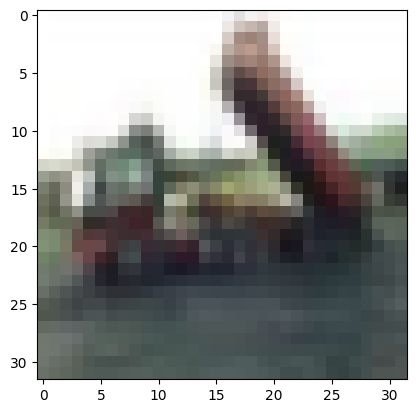

In [6]:
import matplotlib.pyplot as plt

plt.imshow(x_train[2])

In [12]:
# Define the FFNN model
model = Sequential([
    Flatten(input_shape=(32, 32, 3)),  # Flatten the images
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')    # Output layer (10 classes)
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print model summary
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)                  │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 256)                 │         786,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Train the model
history = model.fit(x_train, y_train, epochs=20, batch_size=64, validation_data=(x_test, y_test))
# Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.2784 - loss: 1.9962 - val_accuracy: 0.3727 - val_loss: 1.7395
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3930 - loss: 1.7023 - val_accuracy: 0.4139 - val_loss: 1.6328
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4210 - loss: 1.6168 - val_accuracy: 0.4329 - val_loss: 1.5909
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4422 - loss: 1.5659 - val_accuracy: 0.4182 - val_loss: 1.6427
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4601 - loss: 1.5187 - val_accuracy: 0.4556 - val_loss: 1.5487
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4736 - loss: 1.4765 - val_accuracy: 0.4512 - val_loss: 1.5478
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4790 - loss: 1.4658 - val_accuracy: 0.4678 - val_loss: 1.4976
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4907 - loss: 1.4331 - val_accuracy: 0.

trying it with different layers 3  layers

In [9]:
# Define the FFNN model
model3 = Sequential([
    Flatten(input_shape=(32, 32, 3)),  # Flatten the images
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128,activation = 'relu'),
    Dense(10, activation='softmax')    # Output layer (10 classes)
])

# Compile the model
model3.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print model summary
model3.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)                  │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 256)                 │         786,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 837,386 (3.19 MB)

 Trainable params: 837,386 (3.19 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train the model
history3 = model3.fit(x_train, y_train, epochs=20, batch_size=64, validation_data=(x_test, y_test))
# Evaluate on test data
test_loss3, test_acc3 = model3.evaluate(x_test, y_test, verbose=2)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6401 - loss: 1.0033 - val_accuracy: 0.4997 - val_loss: 1.5253
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6405 - loss: 0.9985 - val_accuracy: 0.4990 - val_loss: 1.5418
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6400 - loss: 0.9917 - val_accuracy: 0.4997 - val_loss: 1.5344
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6442 - loss: 0.9850 - val_accuracy: 0.5078 - val_loss: 1.5315
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6475 - loss: 0.9778 - val_accuracy: 0.5019 - val_loss: 1.5651
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6509 - loss: 0.9707 - val_accuracy: 0.4982 - val_loss: 1.5567
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6467 - loss: 0.9734 - val_accuracy: 0.5008 - val_loss: 1.5798
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6484 - loss: 0.9711 - val_accuracy: 0.

now trying it with 5layers

In [26]:
# Define the FFNN model
model5 = Sequential([
    Flatten(input_shape=(32, 32, 3)),  # Flatten the images
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64,activation = 'relu'),
    Dense(32,activation='relu'),
    Dense(32,activation='relu'),
    Dense(10, activation='softmax')    # Output layer (10 classes)
])

# Compile the model
model5.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print model summary
model5.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)                  │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 256)                 │         786,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 831,306 (3.17 MB)

 Trainable params: 831,306 (3.17 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Train the model
history5 = model5.fit(x_train, y_train, epochs=20, batch_size=64, validation_data=(x_test, y_test))
# Evaluate on test data
test_loss5, test_acc5 = model5.evaluate(x_test, y_test, verbose=2)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2286 - loss: 2.0583 - val_accuracy: 0.3390 - val_loss: 1.8243
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.3526 - loss: 1.7818 - val_accuracy: 0.3953 - val_loss: 1.6936
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3926 - loss: 1.6756 - val_accuracy: 0.4310 - val_loss: 1.5905
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4242 - loss: 1.5991 - val_accuracy: 0.4442 - val_loss: 1.5575
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4450 - loss: 1.5477 - val_accuracy: 0.4572 - val_loss: 1.5176
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4587 - loss: 1.5101 - val_accuracy: 0.4502 - val_loss: 1.5359
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4718 - loss: 1.4849 - val_accuracy: 0.4463 - val_loss: 1.5298
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4758 - loss: 1.4600 - val_accuracy: 0.

plotting the graph comparison between the kernel of 3 layer and 5 layer matrix

In [40]:
y_pred_3x3 = np.argmax(model3.predict(x_test), axis=1)
y_pred_5x5 = np.argmax(model5.predict(x_test), axis=1)
y_test_labels = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


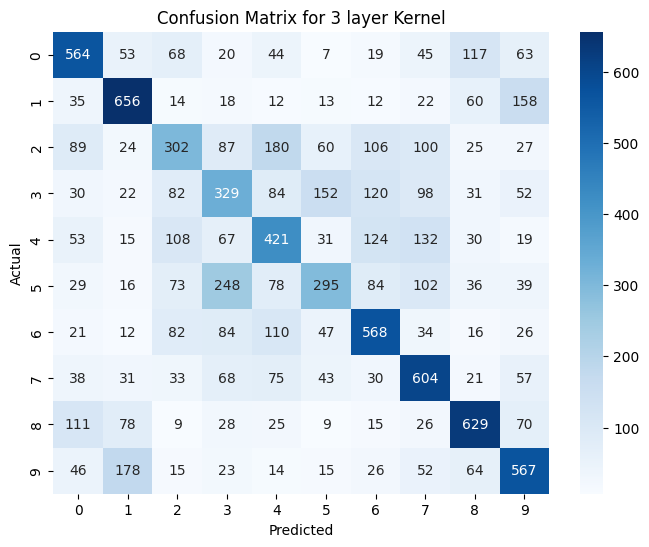

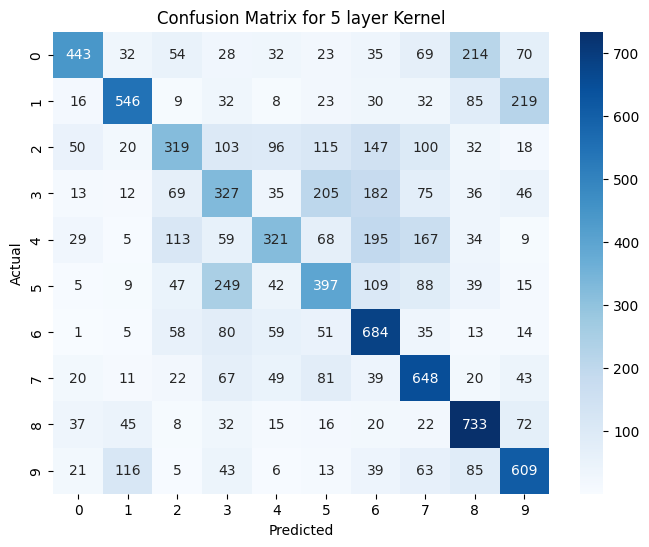

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Function to plot confusion matrices
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

# Plot confusion matrix for 3x3 kernel
plot_confusion_matrix(y_test_labels, y_pred_3x3, "Confusion Matrix for 3 layer Kernel")

# Plot confusion matrix for 5x5 kernel
plot_confusion_matrix(y_test_labels, y_pred_5x5, "Confusion Matrix for 5 layer Kernel")


plotting of graph for kernel size 3 LAYER and 5 LAYER

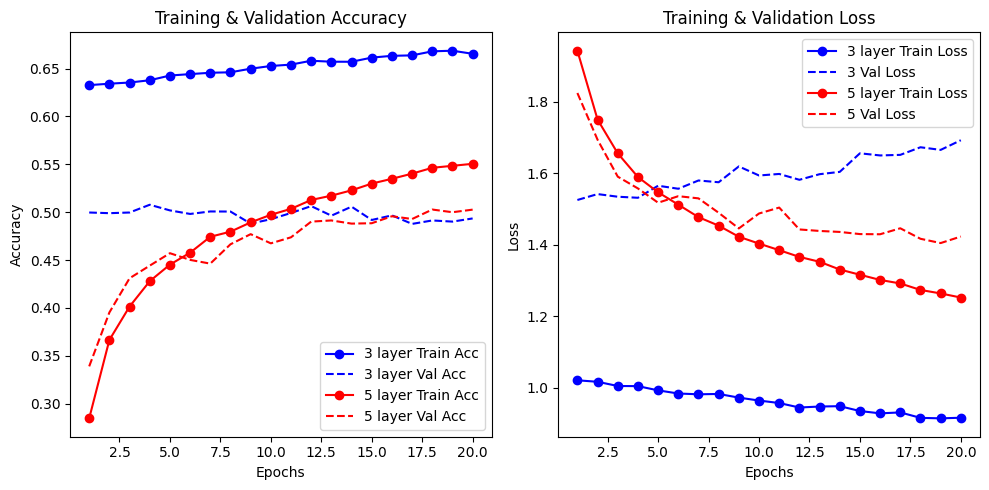

In [47]:
import matplotlib.pyplot as plt

# Extract accuracy and loss values
epochs = range(1, len(history3.history['accuracy']) + 1)  # Update based on actual number of epochs

acc_3x3 = history3.history['accuracy']
val_acc_3x3 = history3.history['val_accuracy']
loss_3x3 = history3.history['loss']
val_loss_3x3 = history3.history['val_loss']

acc_5x5 = history5.history['accuracy']
val_acc_5x5 = history5.history['val_accuracy']
loss_5x5 = history5.history['loss']
val_loss_5x5 = history5.history['val_loss']

plt.figure(figsize=(10, 5))

# Plot Training Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc_3x3, 'b-o', label="3 layer Train Acc")
plt.plot(epochs, val_acc_3x3, 'b--', label="3 layer Val Acc")
plt.plot(epochs, acc_5x5, 'r-o', label="5 layer Train Acc")
plt.plot(epochs, val_acc_5x5, 'r--', label="5 layer Val Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()

# Plot Training Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss_3x3, 'b-o', label="3 layer Train Loss")
plt.plot(epochs, val_loss_3x3, 'b--', label="3 Val Loss")
plt.plot(epochs, loss_5x5, 'r-o', label="5 layer Train Loss")
plt.plot(epochs, val_loss_5x5, 'r--', label="5 Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()


MINI TASK - 2 (TRYING IT WITH DIFFERENT ACTIVATION FUNCTION)

1.Sigmoid

In [49]:
# Define the FFNN model
models = Sequential([
    Flatten(input_shape=(32, 32, 3)),  # Flatten the images
    Dense(256, activation='sigmoid'),
    Dense(128, activation='sigmoid'),
    Dense(64,activation = 'sigmoid'),
    Dense(10, activation='softmax')    # Output layer (10 classes)
])

# Compile the model
models.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print model summary
models.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)                  │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_40 (Dense)                     │ (None, 256)                 │         786,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 828,490 (3.16 MB)

 Trainable params: 828,490 (3.16 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
# Train the model
history_sigmoid = models.fit(x_train, y_train, epochs=20, batch_size=64, validation_data=(x_test, y_test))
# Evaluate on test data
test_loss_s, test_acc_s = models.evaluate(x_test, y_test, verbose=2)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.2444 - loss: 2.0553 - val_accuracy: 0.3297 - val_loss: 1.8281
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.3491 - loss: 1.7943 - val_accuracy: 0.3800 - val_loss: 1.7163
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3771 - loss: 1.7176 - val_accuracy: 0.3896 - val_loss: 1.6811
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3944 - loss: 1.6752 - val_accuracy: 0.4053 - val_loss: 1.6627
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4071 - loss: 1.6403 - val_accuracy: 0.3864 - val_loss: 1.6776
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4192 - loss: 1.6129 - val_accuracy: 0.4185 - val_loss: 1.6080
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4312 - loss: 1.5776 - val_accuracy: 0.4249 - val_loss: 1.6032
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4396 - loss: 1.5501 - val_accuracy: 0.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


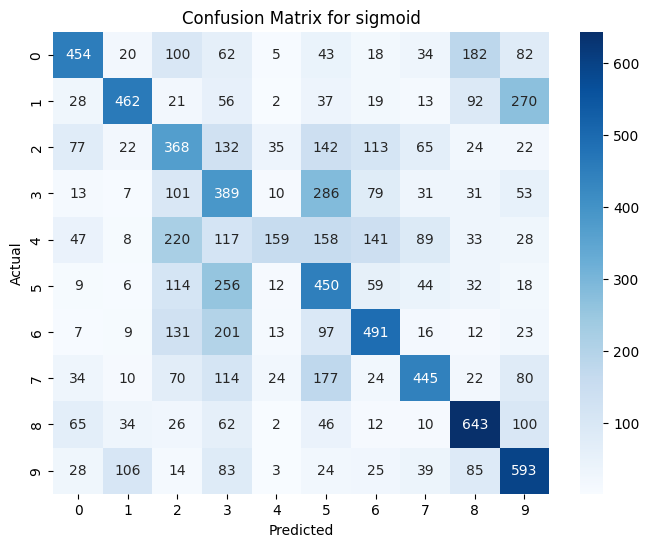

In [55]:
test_sigmoid = np.argmax(models.predict(x_test), axis=1)
plot_confusion_matrix(y_test_labels, test_sigmoid, "Confusion Matrix for sigmoid")

TanH

In [51]:
# Define the FFNN model
modelt = Sequential([
    Flatten(input_shape=(32, 32, 3)),  # Flatten the images
    Dense(256, activation='tanh'),
    Dense(128, activation='tanh'),
    Dense(64,activation = 'tanh'),
    Dense(10, activation='softmax')    # Output layer (10 classes)
])

# Compile the model
modelt.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print model summary
modelt.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)                 │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_44 (Dense)                     │ (None, 256)                 │         786,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_46 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_47 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 828,490 (3.16 MB)

 Trainable params: 828,490 (3.16 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
# Train the model
history_t = modelt.fit(x_train, y_train, epochs=20, batch_size=64, validation_data=(x_test, y_test))
# Evaluate on test data
test_loss_t, test_acc_t = modelt.evaluate(x_test, y_test, verbose=2)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2243 - loss: 2.0839 - val_accuracy: 0.3248 - val_loss: 1.8623
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.3239 - loss: 1.8610 - val_accuracy: 0.3504 - val_loss: 1.8232
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3401 - loss: 1.8206 - val_accuracy: 0.3162 - val_loss: 1.8471
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3473 - loss: 1.8016 - val_accuracy: 0.3579 - val_loss: 1.7734
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3695 - loss: 1.7531 - val_accuracy: 0.3492 - val_loss: 1.8498
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3713 - loss: 1.7506 - val_accuracy: 0.3760 - val_loss: 1.7403
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3802 - loss: 1.7278 - val_accuracy: 0.3822 - val_loss: 1.7236
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3829 - loss: 1.7145 - val_accuracy: 0.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


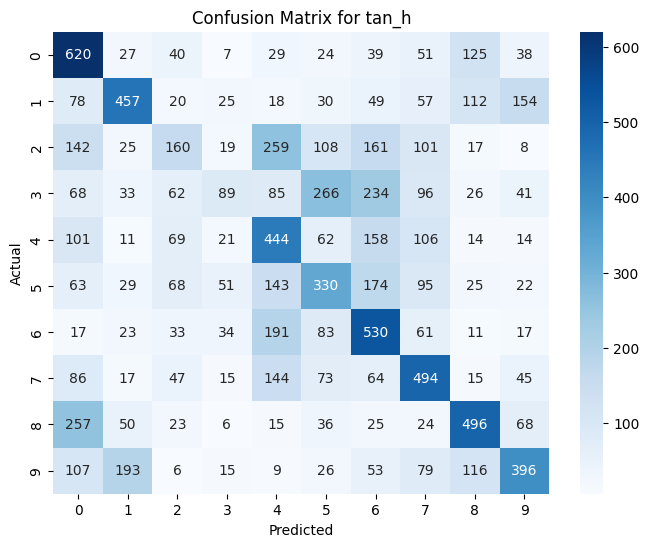

In [54]:
test_tanh = np.argmax(modelt.predict(x_test), axis=1)
plot_confusion_matrix(y_test_labels, test_tanh, "Confusion Matrix for tan_h")

In [56]:
# Define the FFNN model
modelr = Sequential([
    Flatten(input_shape=(32, 32, 3)),  # Flatten the images
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64,activation = 'relu'),
    Dense(10, activation='softmax')    # Output layer (10 classes)
])

# Compile the model
modelr.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print model summary
modelr.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)                 │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_48 (Dense)                     │ (None, 256)                 │         786,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_51 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 828,490 (3.16 MB)

 Trainable params: 828,490 (3.16 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# Train the model
history_r = modelr.fit(x_train, y_train, epochs=20, batch_size=64, validation_data=(x_test, y_test))
# Evaluate on test data
test_loss_t, test_acc_t = modelr.evaluate(x_test, y_test, verbose=2)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.2708 - loss: 1.9895 - val_accuracy: 0.3789 - val_loss: 1.7115
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.3911 - loss: 1.6966 - val_accuracy: 0.4262 - val_loss: 1.6107
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.4203 - loss: 1.6123 - val_accuracy: 0.4340 - val_loss: 1.5696
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4440 - loss: 1.5557 - val_accuracy: 0.4383 - val_loss: 1.5651
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.4579 - loss: 1.5135 - val_accuracy: 0.4552 - val_loss: 1.5197
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4729 - loss: 1.4752 - val_accuracy: 0.4706 - val_loss: 1.4840
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4805 - loss: 1.4566 - val_accuracy: 0.4688 - val_loss: 1.5012
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4895 - loss: 1.4288 - val_accuracy: 0.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


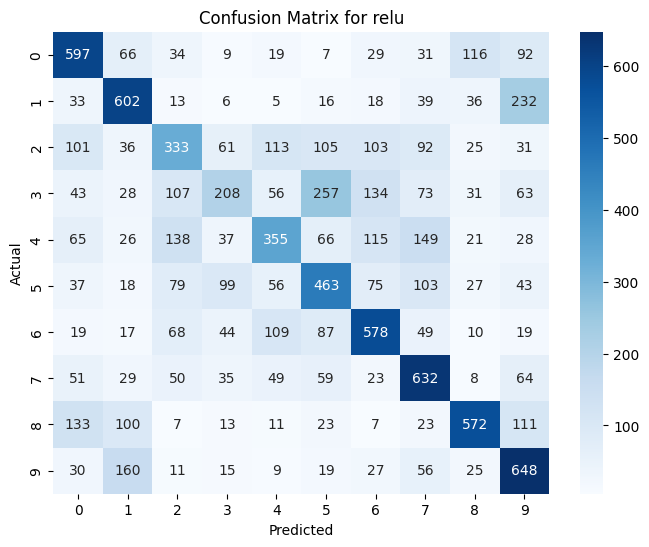

In [59]:
test_relu = np.argmax(modelr.predict(x_test), axis=1)
plot_confusion_matrix(y_test_labels, test_relu, "Confusion Matrix for relu")

PLOT of comaprison between tanh , sigmoid and relu

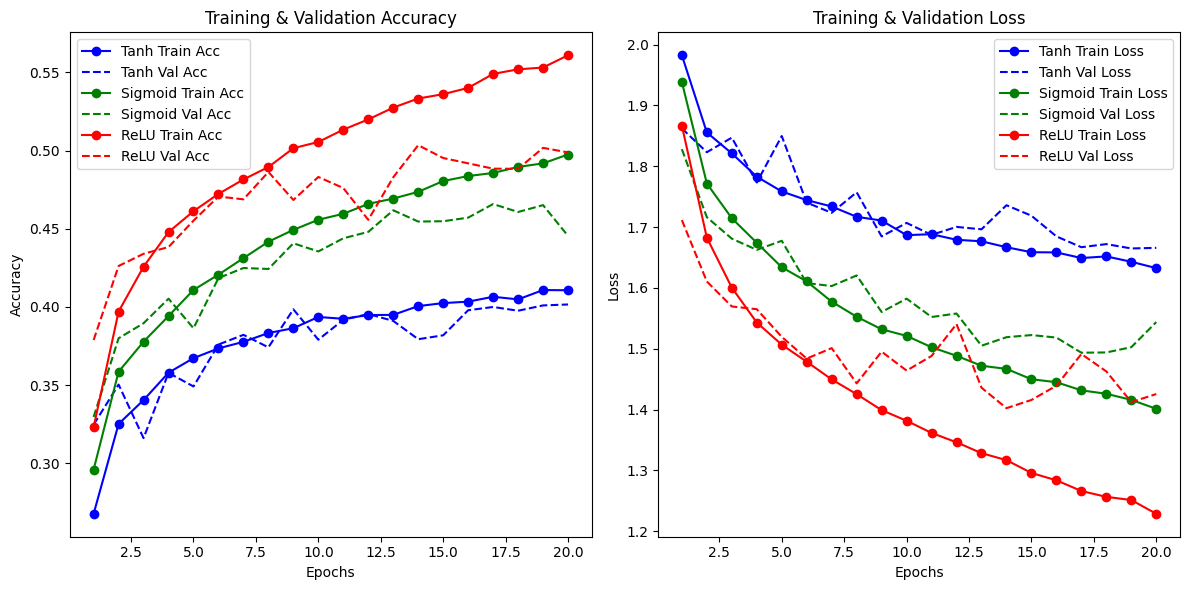

In [61]:
import matplotlib.pyplot as plt

# Assuming you've already trained models with 'tanh', 'sigmoid', and 'relu' activations
# and stored the histories in 'history_tanh', 'history_sigmoid', and 'history_relu'

# Extract accuracy and loss values for all three models
epochs = range(1, len(history_t.history['accuracy']) + 1)  # Use dynamic epoch range

acc_tanh = history_t.history['accuracy']
val_acc_tanh = history_t.history['val_accuracy']
loss_tanh = history_t.history['loss']
val_loss_tanh = history_t.history['val_loss']

acc_sigmoid = history_sigmoid.history['accuracy']
val_acc_sigmoid = history_sigmoid.history['val_accuracy']
loss_sigmoid = history_sigmoid.history['loss']
val_loss_sigmoid = history_sigmoid.history['val_loss']

acc_relu = history_r.history['accuracy']
val_acc_relu = history_r.history['val_accuracy']
loss_relu = history_r.history['loss']
val_loss_relu = history_r.history['val_loss']

# Create a figure for comparison
plt.figure(figsize=(12, 6))

# Plot Training Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc_tanh, 'b-o', label="Tanh Train Acc")
plt.plot(epochs, val_acc_tanh, 'b--', label="Tanh Val Acc")
plt.plot(epochs, acc_sigmoid, 'g-o', label="Sigmoid Train Acc")
plt.plot(epochs, val_acc_sigmoid, 'g--', label="Sigmoid Val Acc")
plt.plot(epochs, acc_relu, 'r-o', label="ReLU Train Acc")
plt.plot(epochs, val_acc_relu, 'r--', label="ReLU Val Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()

# Plot Training Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss_tanh, 'b-o', label="Tanh Train Loss")
plt.plot(epochs, val_loss_tanh, 'b--', label="Tanh Val Loss")
plt.plot(epochs, loss_sigmoid, 'g-o', label="Sigmoid Train Loss")
plt.plot(epochs, val_loss_sigmoid, 'g--', label="Sigmoid Val Loss")
plt.plot(epochs, loss_relu, 'r-o', label="ReLU Train Loss")
plt.plot(epochs, val_loss_relu, 'r--', label="ReLU Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()


TASK - 2 (Implement a Basic CNN for CIFAR-10)

In [65]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D
# Build the CNN model
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])
cnn_model.summary()
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the CNN model
cnn_history_3max = cnn_model.fit(x_train, y_train, epochs=20, batch_size=64, validation_split=0.2)

# Evaluate the CNN model
cnn_loss, cnn_accuracy = cnn_model.evaluate(x_test, y_test)
print(f"CNN Test accuracy: {cnn_accuracy:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_12 (Flatten)                 │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_52 (Dense)                     │ (None, 32)                  │          73,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_53 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_54 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 94,538 (369.29 KB)

 Trainable params: 94,538 (369.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.2882 - loss: 1.9177 - val_accuracy: 0.4703 - val_loss: 1.4733
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5102 - loss: 1.3710 - val_accuracy: 0.5510 - val_loss: 1.2802
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5780 - loss: 1.2054 - val_accuracy: 0.5763 - val_loss: 1.1972
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6154 - loss: 1.0936 - val_accuracy: 0.6256 - val_loss: 1.0780
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6458 - loss: 1.0167 - val_accuracy: 0.6366 - val_loss: 1.0502
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6545 - loss: 0.9880 - val_accuracy: 0.6383 - val_loss: 1.0523
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6818 - loss: 0.9186 - val_accuracy: 0.6616 - val_loss: 0.9828
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6894 - loss: 0.8968 - val_accuracy: 0.

MINI TASK 3 (instead of max pooling do average pooling)

In [66]:
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential

# Build the CNN model with Average Pooling
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    AveragePooling2D((2, 2)),  # Replaced MaxPooling2D with AveragePooling2D
    Conv2D(64, (3, 3), activation='relu'),
    AveragePooling2D((2, 2)),  # Replaced MaxPooling2D with AveragePooling2D
    Flatten(),
    Dense(32, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

# Print model summary
cnn_model.summary()

# Compile the model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the CNN model
cnn_history_3avg = cnn_model.fit(x_train, y_train, epochs=20, batch_size=64, validation_split=0.2)

# Evaluate the CNN model
cnn_loss, cnn_accuracy = cnn_model.evaluate(x_test, y_test)
print(f"CNN Test accuracy: {cnn_accuracy:.4f}")


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d (AveragePooling2D) │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_1                  │ (None, 6, 6, 64)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_13 (Flatten)                 │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_55 (Dense)                     │ (None, 32)                  │          73,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_56 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_57 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 94,538 (369.29 KB)

 Trainable params: 94,538 (369.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2751 - loss: 1.9543 - val_accuracy: 0.4509 - val_loss: 1.5132
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4680 - loss: 1.4585 - val_accuracy: 0.5128 - val_loss: 1.3711
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5239 - loss: 1.3226 - val_accuracy: 0.5574 - val_loss: 1.2634
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5592 - loss: 1.2375 - val_accuracy: 0.5705 - val_loss: 1.2232
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5860 - loss: 1.1595 - val_accuracy: 0.5999 - val_loss: 1.1521
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6174 - loss: 1.0827 - val_accuracy: 0.6153 - val_loss: 1.1088
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6401 - loss: 1.0231 - val_accuracy: 0.6344 - val_loss: 1.0423
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6603 - loss: 0.9691 - val_accuracy: 0.

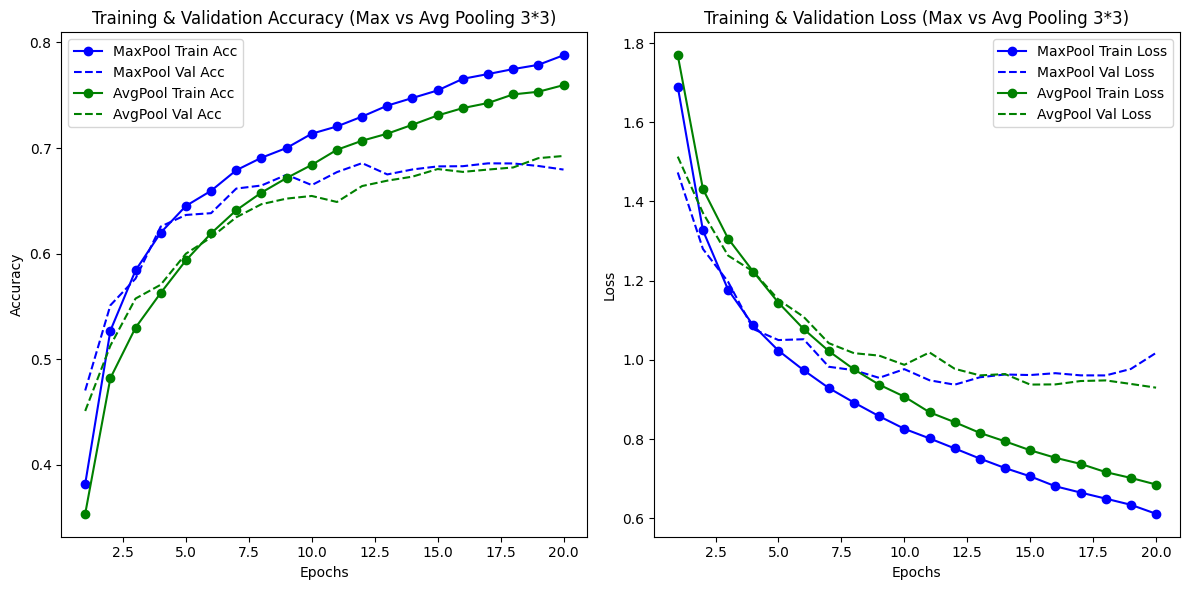

In [70]:
import matplotlib.pyplot as plt

# Assuming you've already trained models with 'MaxPooling2D' and 'AveragePooling2D' activations
# and stored the histories in 'history_max_pool' and 'history_avg_pool'

# Extract accuracy and loss values for both models
epochs = range(1, len(cnn_history_3avg.history['accuracy']) + 1)  # Use dynamic epoch range

acc_max_pool = cnn_history_3max.history['accuracy']
val_acc_max_pool = cnn_history_3max.history['val_accuracy']
loss_max_pool = cnn_history_3max.history['loss']
val_loss_max_pool = cnn_history_3max.history['val_loss']

acc_avg_pool = cnn_history_3avg.history['accuracy']
val_acc_avg_pool = cnn_history_3avg.history['val_accuracy']
loss_avg_pool = cnn_history_3avg.history['loss']
val_loss_avg_pool = cnn_history_3avg.history['val_loss']

# Create a figure for comparison
plt.figure(figsize=(12, 6))

# Plot Training Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc_max_pool, 'b-o', label="MaxPool Train Acc")
plt.plot(epochs, val_acc_max_pool, 'b--', label="MaxPool Val Acc")
plt.plot(epochs, acc_avg_pool, 'g-o', label="AvgPool Train Acc")
plt.plot(epochs, val_acc_avg_pool, 'g--', label="AvgPool Val Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy (Max vs Avg Pooling 3*3)")
plt.legend()

# Plot Training Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss_max_pool, 'b-o', label="MaxPool Train Loss")
plt.plot(epochs, val_loss_max_pool, 'b--', label="MaxPool Val Loss")
plt.plot(epochs, loss_avg_pool, 'g-o', label="AvgPool Train Loss")
plt.plot(epochs, val_loss_avg_pool, 'g--', label="AvgPool Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (Max vs Avg Pooling 3*3)")
plt.legend()

plt.tight_layout()
plt.show()


MINI TASK - 4(change in the kernel size and observe the difference)

chnaging into 5*5 kernel size avg pool

In [72]:
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential

# Build the CNN model with Average Pooling
cnn_model = Sequential([
    Conv2D(32, (5, 5), activation='relu', input_shape=(32, 32, 3)),
    AveragePooling2D((2, 2)),  # Replaced MaxPooling2D with AveragePooling2D
    Conv2D(64, (5, 5), activation='relu'),
    AveragePooling2D((2, 2)),  # Replaced MaxPooling2D with AveragePooling2D
    Flatten(),
    Dense(32, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax') ###yehh galat haib hai pooling nhi
])

# Print model summary
cnn_model.summary()

# Compile the model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the CNN model
cnn_history_5avg = cnn_model.fit(x_train, y_train, epochs=20, batch_size=64, validation_split=0.2)

# Evaluate the CNN model
cnn_loss, cnn_accuracy = cnn_model.evaluate(x_test, y_test)
print(f"CNN Test accuracy: {cnn_accuracy:.4f}")


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 28, 28, 32)          │           2,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_4                  │ (None, 14, 14, 32)          │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 10, 10, 64)          │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_5                  │ (None, 5, 5, 64)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_16 (Flatten)                 │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_64 (Dense)                     │ (None, 32)                  │          51,232 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_65 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_66 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 106,314 (415.29 KB)

 Trainable params: 106,314 (415.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2671 - loss: 1.9579 - val_accuracy: 0.4516 - val_loss: 1.5133
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4671 - loss: 1.4600 - val_accuracy: 0.5119 - val_loss: 1.3464
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5323 - loss: 1.3054 - val_accuracy: 0.5522 - val_loss: 1.2515
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5729 - loss: 1.2041 - val_accuracy: 0.5720 - val_loss: 1.2137
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5959 - loss: 1.1313 - val_accuracy: 0.6132 - val_loss: 1.1091
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6286 - loss: 1.0496 - val_accuracy: 0.6112 - val_loss: 1.1202
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6443 - loss: 1.0066 - val_accuracy: 0.6246 - val_loss: 1.0752
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6566 - loss: 0.9721 - val_accuracy: 0.

changing the kernel size into 5*5 max pool



In [69]:
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential

# Build the CNN model with Average Pooling
cnn_model = Sequential([
    Conv2D(32, (5, 5), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),  # Replaced MaxPooling2D with AveragePooling2D
    Conv2D(64, (5, 5), activation='relu'),
    MaxPooling2D((2, 2)),  # Replaced MaxPooling2D with AveragePooling2D
    Flatten(),
    Dense(32, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

# Print model summary
cnn_model.summary()

# Compile the model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the CNN model
cnn_history_5max = cnn_model.fit(x_train, y_train, epochs=20, batch_size=64, validation_split=0.2)

# Evaluate the CNN model
cnn_loss, cnn_accuracy = cnn_model.evaluate(x_test, y_test)
print(f"CNN Test accuracy: {cnn_accuracy:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 28, 28, 32)          │           2,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 10, 10, 64)          │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_15 (Flatten)                 │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_61 (Dense)                     │ (None, 32)                  │          51,232 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_62 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_63 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 106,314 (415.29 KB)

 Trainable params: 106,314 (415.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.2824 - loss: 1.9364 - val_accuracy: 0.4899 - val_loss: 1.4310
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5021 - loss: 1.3810 - val_accuracy: 0.5524 - val_loss: 1.2634
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5821 - loss: 1.1859 - val_accuracy: 0.5871 - val_loss: 1.1722
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6139 - loss: 1.0883 - val_accuracy: 0.6237 - val_loss: 1.0783
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6459 - loss: 0.9989 - val_accuracy: 0.6292 - val_loss: 1.0646
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6684 - loss: 0.9446 - val_accuracy: 0.6524 - val_loss: 1.0015
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6937 - loss: 0.8707 - val_accuracy: 0.6504 - val_loss: 1.0276
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7104 - loss: 0.8235 - val_accuracy: 0.

plotting between avg and max for 5*5

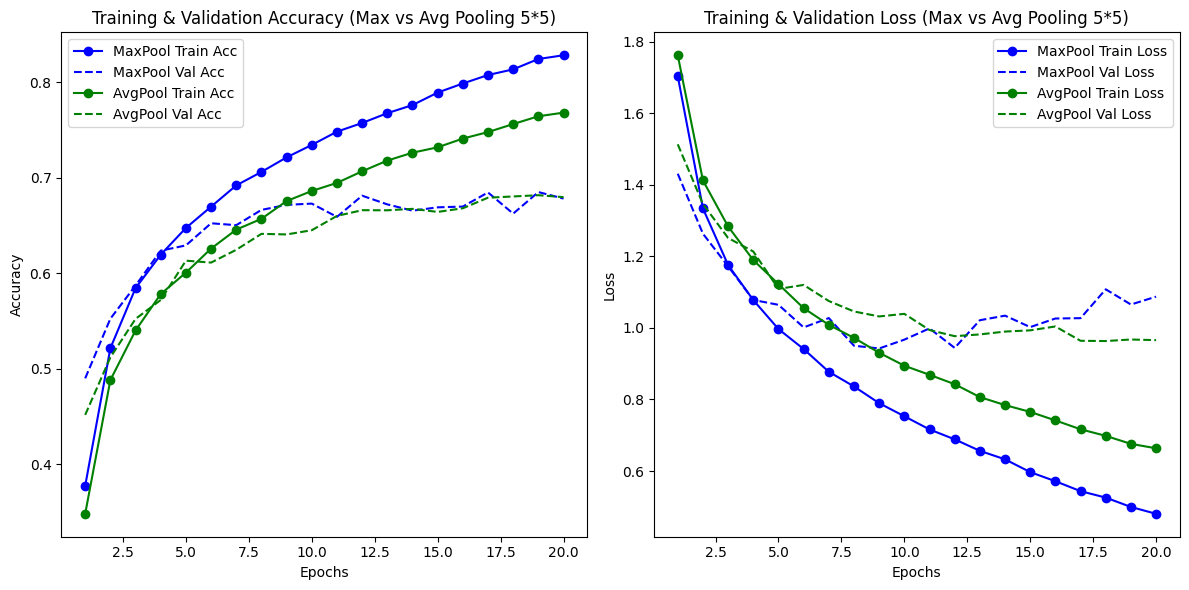

In [74]:
import matplotlib.pyplot as plt

# Assuming you've already trained models with 'MaxPooling2D' and 'AveragePooling2D' activations
# and stored the histories in 'history_max_pool' and 'history_avg_pool'

# Extract accuracy and loss values for both models
epochs = range(1, len(cnn_history_5avg.history['accuracy']) + 1)  # Use dynamic epoch range

acc_max_pool = cnn_history_5max.history['accuracy']
val_acc_max_pool = cnn_history_5max.history['val_accuracy']
loss_max_pool = cnn_history_5max.history['loss']
val_loss_max_pool = cnn_history_5max.history['val_loss']

acc_avg_pool = cnn_history_5avg.history['accuracy']
val_acc_avg_pool = cnn_history_5avg.history['val_accuracy']
loss_avg_pool = cnn_history_5avg.history['loss']
val_loss_avg_pool = cnn_history_5avg.history['val_loss']

# Create a figure for comparison
plt.figure(figsize=(12, 6))

# Plot Training Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc_max_pool, 'b-o', label="MaxPool Train Acc")
plt.plot(epochs, val_acc_max_pool, 'b--', label="MaxPool Val Acc")
plt.plot(epochs, acc_avg_pool, 'g-o', label="AvgPool Train Acc")
plt.plot(epochs, val_acc_avg_pool, 'g--', label="AvgPool Val Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy (Max vs Avg Pooling 5*5)")
plt.legend()

# Plot Training Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss_max_pool, 'b-o', label="MaxPool Train Loss")
plt.plot(epochs, val_loss_max_pool, 'b--', label="MaxPool Val Loss")
plt.plot(epochs, loss_avg_pool, 'g-o', label="AvgPool Train Loss")
plt.plot(epochs, val_loss_avg_pool, 'g--', label="AvgPool Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (Max vs Avg Pooling 5*5)")
plt.legend()

plt.tight_layout()
plt.show()


TASK 3 Improve CNN Using Stride and Padding

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


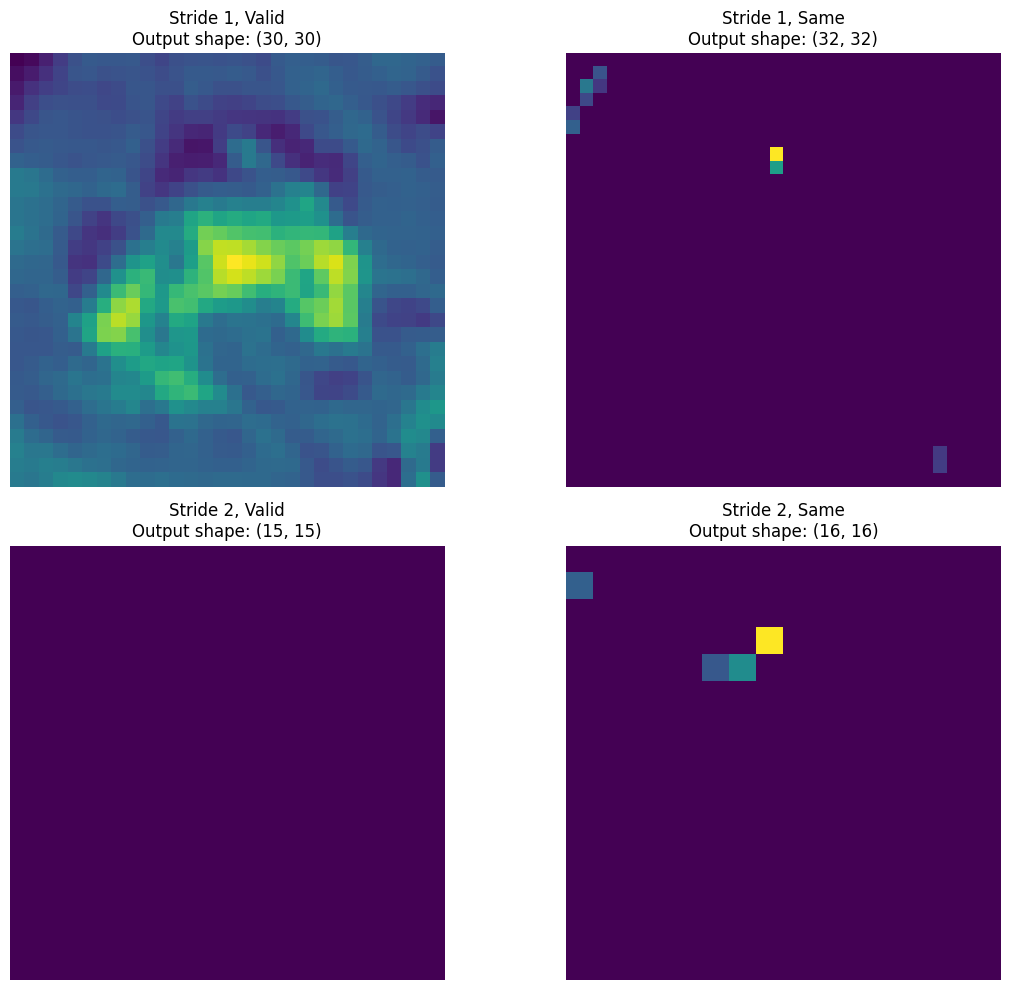

In [76]:
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import Model
from keras import layers
import numpy as np

# Choose one sample image from the training set (shape: 32x32x3)
sample_img = x_train[0:1]  # shape: (1, 32, 32, 3)

def create_model(stride, padding):
    input_layer = layers.Input(shape=(32, 32, 3))
    # Using 16 filters and a kernel size of 3x3
    conv_layer = layers.Conv2D(filters=16, kernel_size=3, strides=stride, padding=padding, activation='relu')(input_layer)
    model = Model(inputs=input_layer, outputs=conv_layer)
    return model

# Define configurations: different combinations of stride and padding
configs = {
    "Stride 1, Valid": create_model(stride=1, padding='valid'),
    "Stride 1, Same": create_model(stride=1, padding='same'),
    "Stride 2, Valid": create_model(stride=2, padding='valid'),
    "Stride 2, Same": create_model(stride=2, padding='same'),
}

# Visualize the feature maps from each configuration
plt.figure(figsize=(12, 10))
for i, (title, model) in enumerate(configs.items()):
    # Get the feature map by running the sample image through the model
    feature_map = model.predict(sample_img)

    # For visualization, use the first channel of the feature map
    fmap = feature_map[0, :, :, 0]

    # Plot the feature map with the output shape in the title
    plt.subplot(2, 2, i+1)
    plt.imshow(fmap, cmap='viridis')
    plt.title(f"{title}\nOutput shape: {feature_map.shape[1:3]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


so now on applying stride and padding properly


In [ ]:
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential

# Build the CNN model with 5x5 pooling kernels
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), strides=(2, 2), padding='same'),
    AveragePooling2D(pool_size=(2, 2)),  # Use strides=2 to avoid shrinking too fast
    Conv2D(64, (3, 3), activation='relu', strides=(2, 2), padding='same'),
    AveragePooling2D(pool_size=(2, 2)),  # Keep padding='same'
    Flatten(),
    Dense(32, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

# Print model summary
cnn_model.summary()

# Compile the model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the CNN model
cnn_history = cnn_model.fit(x_train, y_train, epochs=20, batch_size=64, validation_split=0.2)

# Evaluate the CNN model
cnn_loss, cnn_accuracy = cnn_model.evaluate(x_test, y_test)
print(f"CNN Test accuracy: {cnn_accuracy:.4f}")


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 16, 16, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_6                  │ (None, 8, 8, 32)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 4, 4, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_7                  │ (None, 2, 2, 64)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_9 (Flatten)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 32)                  │           8,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,002 (113.29 KB)

 Trainable params: 29,002 (113.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.2458 - loss: 2.0447 - val_accuracy: 0.3677 - val_loss: 1.7300
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3909 - loss: 1.6592 - val_accuracy: 0.4012 - val_loss: 1.6331
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4361 - loss: 1.5416 - val_accuracy: 0.4285 - val_loss: 1.5441
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4611 - loss: 1.4659 - val_accuracy: 0.4904 - val_loss: 1.4135
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4900 - loss: 1.4015 - val_accuracy: 0.5004 - val_loss: 1.3863
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5017 - loss: 1.3664 - val_accuracy: 0.5151 - val_loss: 1.3392
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5213 - loss: 1.3223 - val_accuracy: 0.5056 - val_loss: 1.3696
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5337 - loss: 1.2985 - val_accuracy: 0.

without any strides and padding

In [ ]:
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential

# Build the CNN model with Average Pooling
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3),padding='same'),
    AveragePooling2D((2, 2)),  # Replaced MaxPooling2D with AveragePooling2D
    Conv2D(64, (3, 3), activation='relu', input_shape=(64,64,3),padding='same'),
    AveragePooling2D((2, 2)),  # Replaced MaxPooling2D with AveragePooling2D
    Flatten(),
    Dense(32, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

# Print model summary
cnn_model.summary()

# Compile the model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the CNN model
cnn_history = cnn_model.fit(x_train, y_train, epochs=30, batch_size=64, validation_split=0.2)

# Evaluate the CNN model
cnn_loss, cnn_accuracy = cnn_model.evaluate(x_test, y_test)
print(f"CNN Test accuracy: {cnn_accuracy:.4f}")


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)                   │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_8                  │ (None, 16, 16, 32)          │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_9                  │ (None, 8, 8, 64)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_10 (Flatten)                 │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 32)                  │         131,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151,882 (593.29 KB)

 Trainable params: 151,882 (593.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2992 - loss: 1.9169 - val_accuracy: 0.4737 - val_loss: 1.4398
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5060 - loss: 1.3613 - val_accuracy: 0.5388 - val_loss: 1.2872
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5703 - loss: 1.1982 - val_accuracy: 0.5939 - val_loss: 1.1486
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6109 - loss: 1.0860 - val_accuracy: 0.6227 - val_loss: 1.0675
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6382 - loss: 1.0153 - val_accuracy: 0.6245 - val_loss: 1.0748
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6628 - loss: 0.9471 - val_accuracy: 0.6255 - val_loss: 1.0639
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6844 - loss: 0.8914 - val_accuracy: 0.6483 - val_loss: 1.0036
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6963 - loss: 0.8549 - val_accuracy: 0.

valid

In [ ]:
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential

# Build the CNN model with Average Pooling
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3),padding='valid'),
    AveragePooling2D((2, 2)),  # Replaced MaxPooling2D with AveragePooling2D
    Conv2D(64, (3, 3), activation='relu', input_shape=(64,64,3),padding='valid'),
    AveragePooling2D((2, 2)),  # Replaced MaxPooling2D with AveragePooling2D
    Flatten(),
    Dense(32, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

# Print model summary
cnn_model.summary()

# Compile the model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the CNN model
cnn_history = cnn_model.fit(x_train, y_train, epochs=30, batch_size=64, validation_split=0.2)

# Evaluate the CNN model
cnn_loss, cnn_accuracy = cnn_model.evaluate(x_test, y_test)
print(f"CNN Test accuracy: {cnn_accuracy:.4f}")


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_2                  │ (None, 15, 15, 32)          │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_3                  │ (None, 6, 6, 64)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │          73,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 94,538 (369.29 KB)

 Trainable params: 94,538 (369.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 68ms/step - accuracy: 0.2709 - loss: 1.9552 - val_accuracy: 0.4583 - val_loss: 1.5101
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 65ms/step - accuracy: 0.4721 - loss: 1.4445 - val_accuracy: 0.5030 - val_loss: 1.3846
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.5309 - loss: 1.3033 - val_accuracy: 0.5463 - val_loss: 1.2795
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 68ms/step - accuracy: 0.5619 - loss: 1.2100 - val_accuracy: 0.5577 - val_loss: 1.2278
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 67ms/step - accuracy: 0.6033 - loss: 1.1100 - val_accuracy: 0.6062 - val_loss: 1.1306
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - accuracy: 0.6210 - loss: 1.0653 - val_accuracy: 0.6159 - val_loss: 1.0797
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.6438 - loss: 1.0078 - val_accuracy: 0.6309 - val_loss: 1.0523
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 65ms/step - accuracy: 0.6567 - loss: 0.9721 - 

Now on applying proper padding and strides

1. keeping the strides as 2 instead of 1

In [ ]:
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential


cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3),strides=(2, 2)),
    AveragePooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu',input_shape = (64,64,3),strides=(2, 2)),
    AveragePooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

# Print model summary
cnn_model.summary()

# Compile the model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the CNN model
cnn_history = cnn_model.fit(x_train, y_train, epochs=30, batch_size=64, validation_split=0.2)

# Evaluate the CNN model
cnn_loss, cnn_accuracy = cnn_model.evaluate(x_test, y_test)
print(f"CNN Test accuracy: {cnn_accuracy:.4f}")


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 15, 15, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_4                  │ (None, 7, 7, 32)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 3, 3, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_5                  │ (None, 1, 1, 64)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,858 (89.29 KB)

 Trainable params: 22,858 (89.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.1949 - loss: 2.1200 - val_accuracy: 0.2906 - val_loss: 1.8898
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.3046 - loss: 1.8490 - val_accuracy: 0.3279 - val_loss: 1.7858
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.3442 - loss: 1.7510 - val_accuracy: 0.3697 - val_loss: 1.6908
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.3816 - loss: 1.6806 - val_accuracy: 0.3891 - val_loss: 1.6507
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.4023 - loss: 1.6220 - val_accuracy: 0.3900 - val_loss: 1.6170
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.4131 - loss: 1.5870 - val_accuracy: 0.4102 - val_loss: 1.5842
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.4294 - loss: 1.5534 - val_accuracy: 0.4232 - val_loss: 1.5616
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4490 - loss: 1.5130 - val_a

on changing padding to same and keeping strides to 1

In [ ]:
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential


cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3),strides=(1, 1)),
    AveragePooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu',input_shape = (64,64,3),strides=(1, 1)),
    AveragePooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

# Print model summary
cnn_model.summary()

# Compile the model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the CNN model
cnn_history = cnn_model.fit(x_train, y_train, epochs=30, batch_size=64, validation_split=0.2)

# Evaluate the CNN model
cnn_loss, cnn_accuracy = cnn_model.evaluate(x_test, y_test)
print(f"CNN Test accuracy: {cnn_accuracy:.4f}")


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_8                  │ (None, 15, 15, 32)          │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_9                  │ (None, 6, 6, 64)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 32)                  │          73,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 94,538 (369.29 KB)

 Trainable params: 94,538 (369.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 75ms/step - accuracy: 0.2721 - loss: 1.9663 - val_accuracy: 0.4450 - val_loss: 1.5118
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.4794 - loss: 1.4436 - val_accuracy: 0.5212 - val_loss: 1.3517
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 67ms/step - accuracy: 0.5384 - loss: 1.2918 - val_accuracy: 0.5514 - val_loss: 1.2551
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 70ms/step - accuracy: 0.5747 - loss: 1.1973 - val_accuracy: 0.5907 - val_loss: 1.1609
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.6047 - loss: 1.1159 - val_accuracy: 0.5898 - val_loss: 1.1564
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 66ms/step - accuracy: 0.6312 - loss: 1.0483 - val_accuracy: 0.6249 - val_loss: 1.0904
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 66ms/step - accuracy: 0.6506 - loss: 0.9946 - val_accuracy: 0.6347 - val_loss: 1.0554
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 66ms/step - accuracy: 0.6676 - loss: 0.9513 - 

TASK - 4 Enhance CNN Model with Regularization

Without drop out

In [97]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2

# Build the CNN model with regularization techniques
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001), input_shape=(32, 32, 3)),
    BatchNormalization(),
    AveragePooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    AveragePooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.0),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.0),
    Dense(10, activation='softmax')
])

# Print model summary
cnn_model.summary()

# Compile the model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the CNN model without data augmentation
cnn_history = cnn_model.fit(
    x_train, y_train, batch_size=64, epochs=25, validation_data=(x_test, y_test)
)

# Evaluate the CNN model
cnn_loss, cnn_accuracy = cnn_model.evaluate(x_test, y_test)
print(f"New CNN Test Accuracy: {cnn_accuracy:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)                   │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_20               │ (None, 30, 30, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_26                 │ (None, 15, 15, 32)          │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_35 (Conv2D)                   │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_21               │ (None, 13, 13, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_27                 │ (None, 6, 6, 64)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_27 (Flatten)                 │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_97 (Dense)                     │ (None, 64)                  │         147,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_98 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_99 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 169,706 (662.91 KB)

 Trainable params: 169,514 (662.16 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.4453 - loss: 1.7859 - val_accuracy: 0.5799 - val_loss: 1.3805
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6555 - loss: 1.1926 - val_accuracy: 0.6006 - val_loss: 1.3375
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7111 - loss: 1.0296 - val_accuracy: 0.4153 - val_loss: 2.3595
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7486 - loss: 0.9352 - val_accuracy: 0.6517 - val_loss: 1.2560
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7697 - loss: 0.8857 - val_accuracy: 0.6202 - val_loss: 1.3620
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7948 - loss: 0.8345 - val_accuracy: 0.6765 - val_loss: 1.2305
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8125 - loss: 0.7966 - val_accuracy: 0.6874 - val_loss: 1.2296
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8229 - loss: 0.7704 - val_accuracy:

with dropout

In [87]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Apply Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Build the CNN model with regularization techniques
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001), input_shape=(32, 32, 3)),
    BatchNormalization(),
    AveragePooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    AveragePooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),  # Drop 50% of neurons to prevent overfitting
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),  # Drop 30% of neurons
    Dense(10, activation='softmax')  # Output layer
])

# Print model summary
cnn_model.summary()

# Compile the model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the CNN model with data augmentation
cnn_history_drop = cnn_model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=25,
    validation_data=(x_test, y_test)
)

# Evaluate the CNN model
cnn_loss, cnn_accuracy = cnn_model.evaluate(x_test, y_test)
print(f"New CNN Test Accuracy: {cnn_accuracy:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)                   │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 30, 30, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_16                 │ (None, 15, 15, 32)          │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_25 (Conv2D)                   │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 13, 13, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_17                 │ (None, 6, 6, 64)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_22 (Flatten)                 │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_82 (Dense)                     │ (None, 64)                  │         147,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_83 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_84 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 169,706 (662.91 KB)

 Trainable params: 169,514 (662.16 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/25


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 51ms/step - accuracy: 0.2397 - loss: 2.3509 - val_accuracy: 0.4043 - val_loss: 1.7992
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 43ms/step - accuracy: 0.3936 - loss: 1.8333 - val_accuracy: 0.5091 - val_loss: 1.5265
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.4600 - loss: 1.6722 - val_accuracy: 0.4653 - val_loss: 1.7299
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.5023 - loss: 1.5709 - val_accuracy: 0.5705 - val_loss: 1.4006
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.5296 - loss: 1.5130 - val_accuracy: 0.6111 - val_loss: 1.2701
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.5587 - loss: 1.4526 - val_accuracy: 0.6220 - val_loss: 1.2562
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.5587 - loss: 1.4490 - val_accuracy: 0.6112 - val_loss: 1.3026
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.5713 - loss: 1.4331 - val_accurac

without augmentation

In [88]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Build the CNN model with regularization techniques
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001), input_shape=(32, 32, 3)),
    BatchNormalization(),
    AveragePooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    AveragePooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),  # Drop 50% of neurons to prevent overfitting
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),  # Drop 30% of neurons
    Dense(10, activation='softmax')  # Output layer
])

# Print model summary
cnn_model.summary()

# Compile the model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the CNN model with data augmentation
cnn_history_wo_aug = cnn_model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=25,
    validation_data=(x_test, y_test)
)

# Evaluate the CNN model
cnn_loss, cnn_accuracy = cnn_model.evaluate(x_test, y_test)
print(f"New CNN Test Accuracy: {cnn_accuracy:.4f}")


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)                   │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 30, 30, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_18                 │ (None, 15, 15, 32)          │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_27 (Conv2D)                   │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 13, 13, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_19                 │ (None, 6, 6, 64)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_23 (Flatten)                 │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_85 (Dense)                     │ (None, 64)                  │         147,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_86 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_87 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 169,706 (662.91 KB)

 Trainable params: 169,514 (662.16 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step - accuracy: 0.2307 - loss: 2.3623 - val_accuracy: 0.3766 - val_loss: 1.8854
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.3875 - loss: 1.8532 - val_accuracy: 0.5295 - val_loss: 1.4951
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.4605 - loss: 1.6718 - val_accuracy: 0.5546 - val_loss: 1.4085
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.4971 - loss: 1.5791 - val_accuracy: 0.5748 - val_loss: 1.3543
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.5160 - loss: 1.5402 - val_accuracy: 0.5890 - val_loss: 1.3326
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.5375 - loss: 1.5015 - val_accuracy: 0.5868 - val_loss: 1.3464
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.5464 - loss: 1.4823 - val_accuracy: 0.6196 - val_loss: 1.2751
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.5598 - loss: 1.4564 - 

with augmentation

In [89]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Apply Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Build the CNN model with regularization techniques
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001), input_shape=(32, 32, 3)),
    BatchNormalization(),
    AveragePooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    AveragePooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),  # Drop 50% of neurons to prevent overfitting
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),  # Drop 30% of neurons
    Dense(10, activation='softmax')  # Output layer
])

# Print model summary
cnn_model.summary()

# Compile the model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the CNN model with data augmentation
cnn_history_w_aug = cnn_model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=25,
    validation_data=(x_test, y_test)
)

# Evaluate the CNN model
cnn_loss, cnn_accuracy = cnn_model.evaluate(x_test, y_test)
print(f"New CNN Test Accuracy: {cnn_accuracy:.4f}")


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)                   │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 30, 30, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_20                 │ (None, 15, 15, 32)          │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_29 (Conv2D)                   │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 13, 13, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_21                 │ (None, 6, 6, 64)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_24 (Flatten)                 │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_88 (Dense)                     │ (None, 64)                  │         147,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_89 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_90 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 169,706 (662.91 KB)

 Trainable params: 169,514 (662.16 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - accuracy: 0.2233 - loss: 2.4270 - val_accuracy: 0.4564 - val_loss: 1.7683
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.3839 - loss: 1.8615 - val_accuracy: 0.4736 - val_loss: 1.6194
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.4605 - loss: 1.6694 - val_accuracy: 0.5431 - val_loss: 1.4154
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.5004 - loss: 1.5823 - val_accuracy: 0.4904 - val_loss: 1.7343
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.5229 - loss: 1.5286 - val_accuracy: 0.5492 - val_loss: 1.5375
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.5430 - loss: 1.4945 - val_accuracy: 0.6119 - val_loss: 1.2917
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.5595 - loss: 1.4581 - val_accuracy: 0.6479 - val_loss: 1.1890
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.5727 - loss: 1.4323 - 

plotting graph against data augmentation, L2 regularisation, drop_out

In [98]:
print(len(cnn_history.history['val_accuracy']))
print(len(cnn_history_drop.history['val_accuracy']))
print(len(cnn_history_w_aug.history['val_accuracy']))
print(len(cnn_history_wo_aug.history['val_accuracy']))


25
25
25
25


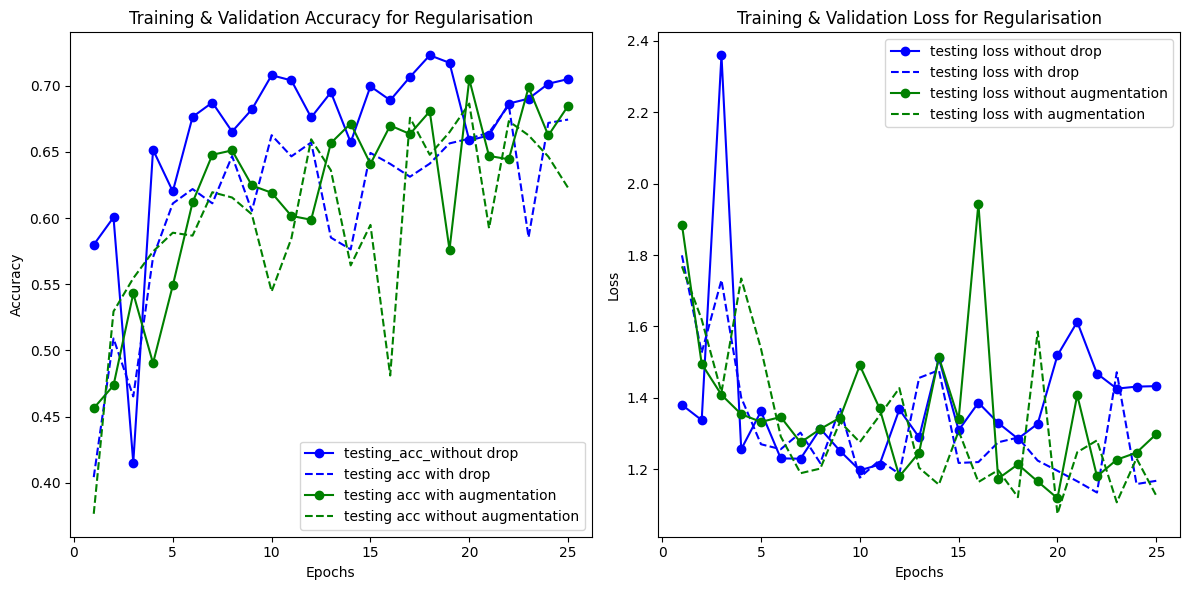

In [99]:
import matplotlib.pyplot as plt

# Assuming you've already trained models with 'MaxPooling2D' and 'AveragePooling2D' activations
# and stored the histories in 'history_max_pool' and 'history_avg_pool'

# Extract accuracy and loss values for both models
epochs = range(1, len(cnn_history_drop.history['accuracy']) + 1)  # Use dynamic epoch range

val_acc_wo_drop = cnn_history.history['val_accuracy']
val_loss_wo_drop = cnn_history.history['val_loss']

val_acc_w_drop = cnn_history_drop.history['val_accuracy']
val_loss_w_drop = cnn_history_drop.history['val_loss']

val_acc_w_aug = cnn_history_w_aug.history['val_accuracy']
val_loss_w_aug = cnn_history_w_aug.history['val_loss']

val_acc_wo_aug = cnn_history_wo_aug.history['val_accuracy']
val_loss_wo_aug = cnn_history_wo_aug.history['val_loss']


# Create a figure for comparison
plt.figure(figsize=(12, 6))

# Plot Training Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, val_acc_wo_drop, 'b-o', label="testing_acc_without drop")
plt.plot(epochs, val_acc_w_drop, 'b--', label="testing acc with drop")
plt.plot(epochs, val_acc_w_aug, 'g-o', label="testing acc with augmentation")
plt.plot(epochs, val_acc_wo_aug, 'g--', label="testing acc without augmentation")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy for Regularisation")
plt.legend()

# Plot Training Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, val_loss_wo_drop, 'b-o', label="testing loss without drop")
plt.plot(epochs, val_loss_w_drop, 'b--', label="testing loss with drop")
plt.plot(epochs, val_loss_wo_aug, 'g-o', label="testing loss without augmentation")
plt.plot(epochs, val_loss_w_aug, 'g--', label="testing loss with augmentation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss for Regularisation")
plt.legend()

plt.tight_layout()
plt.show()
